In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
cngen = pd.read_csv("CN General Catalogues.csv", date_format='%Y-%m-%d')
cncpi = pd.read_csv("CN CPI index.csv", date_format='%Y-%m-%d')
cnspe = pd.read_csv("CN Specific Catalogues.csv", date_format='%Y-%m-%d')

cngen['Date'] = pd.to_datetime(cngen['Date'])
cncpi['Date'] = pd.to_datetime(cncpi['Date'])
cnspe['Date'] = pd.to_datetime(cnspe['Date'])

In [77]:
def fill_lunar_new_year_sales(
    df: pd.DataFrame,
    sales_col: str,
    cumulative_col: str,
    date_col: str = 'Date',
) -> pd.DataFrame:
    """
    Estimates missing Jan/Feb monthly retail sales using the combined Jan-Feb
    cumulative figure, proportioned by each month's share of the two-month window.

    China often reports Jan and Feb retail sales as a single cumulative figure
    to smooth out Lunar New Year timing effects. This function back-calculates
    individual monthly values using a days-in-month weighting.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe containing datetime and retail sales columns.
    date_col : str
        Name of the datetime column.
    sales_col : str
        Monthly retail sales column (may contain NaNs for Jan/Feb).
    cumulative_col : str
        Combined Jan-Feb cumulative sales column used to derive estimates.

    Returns
    -------
    pd.DataFrame
        Copy of df with missing Jan/Feb sales values estimated.
    """
    lunar_mask = df[date_col].dt.month.isin([1, 2]) & df[sales_col].isna()
    lunar = df.loc[lunar_mask, [date_col, sales_col, cumulative_col]].copy()

    lunar[cumulative_col] = lunar[cumulative_col].ffill()

    jan1 = pd.to_datetime(lunar[date_col].dt.year.astype(str) + '-01-01')
    mar1 = pd.to_datetime(lunar[date_col].dt.year.astype(str) + '-03-01')
    days_janfeb = (mar1 - jan1).dt.days

    lunar[sales_col] = (
        lunar[date_col].dt.days_in_month / days_janfeb * lunar[cumulative_col]
    )

    result = df.merge(
        lunar[[date_col, sales_col]],
        on=date_col,
        how='left',
        suffixes=('', '_est'),
    )
    result[sales_col] = result[sales_col].combine_first(result[f'{sales_col}_est'])
    result = result.drop(columns=[f'{sales_col}_est'])

    return result


In [78]:
genlunar = cngen[
    (cngen['Date'].dt.month.isin([1, 2])) &
    (cngen['Retail Sales (CNY 100M)'].isna())
]

genlunar = genlunar[['Date', 'Retail Sales (CNY 100M)', 'Retail Sales Tot Per Annu (CNY 100M)']]

genlunar['Retail Sales Tot Per Annu (CNY 100M)'] = genlunar['Retail Sales Tot Per Annu (CNY 100M)'].ffill()

days_in_month = genlunar['Date'].dt.days_in_month
jan1 = pd.to_datetime(genlunar['Date'].dt.year.astype(str) + '-01-01')
mar1 = pd.to_datetime(genlunar['Date'].dt.year.astype(str) + '-03-01')
days_janfeb = (mar1 - jan1).dt.days
genlunar['Retail Sales (CNY 100M)'] = (
    days_in_month / days_janfeb *
    genlunar['Retail Sales Tot Per Annu (CNY 100M)']
)

genlunar = genlunar[['Date', 'Retail Sales (CNY 100M)']]

In [79]:
cnadj = cngen.merge(genlunar, on = 'Date', how = 'left', suffixes=('', '_y'))
cnadj['Retail Sales (CNY 100M)'] = cnadj['Retail Sales (CNY 100M)'].combine_first(cnadj['Retail Sales (CNY 100M)_y'])
cnadj = cnadj.drop(columns=['Retail Sales (CNY 100M)_y'])

cnadj = cnadj[['Date', 'Retail Sales (CNY 100M)']].merge(cncpi, on = 'Date')
cnadj['Adjusted Retail Sales (CNY 100M)'] = cnadj['Retail Sales (CNY 100M)'] / cnadj['CPIIndex']

In [80]:
cnadj = cnadj.set_index('Date')
cnadj.head()

,Retail Sales (CNY 100M),CPIIndex,CPIIndex excluding groceries,CPIIndex of Consumer Goods,CPIIndex of Services,CPIIndex of Apparel,CPIIndex excluding Groceries and Energy,Adjusted Retail Sales (CNY 100M)
Date,,,,,,,,
2026-05-01,41090.00000,103.159739,104.968895,102.503371,103.884011,106.220236,103.993839,398.314306
2026-04-01,37246.50000,103.296801,105.067607,102.661624,104.006105,105.634800,104.058064,360.577479
2026-03-01,41616.00000,102.990033,104.349758,102.550862,103.567920,105.913277,103.772638,404.077936
2026-02-01,40851.00339,103.742173,104.602298,102.852579,104.763621,105.487475,104.486188,393.774317
2026-01-01,45227.89661,102.803979,103.786667,102.118296,103.617240,105.565479,103.766955,439.943054


In [81]:
cncpi = cncpi.set_index('Date')
cncpi.head()

,CPIIndex,CPIIndex excluding groceries,CPIIndex of Consumer Goods,CPIIndex of Services,CPIIndex of Apparel,CPIIndex excluding Groceries and Energy
Date,,,,,,
2026-05-01,103.159739,104.968895,102.503371,103.884011,106.220236,103.993839
2026-04-01,103.296801,105.067607,102.661624,104.006105,105.634800,104.058064
2026-03-01,102.990033,104.349758,102.550862,103.567920,105.913277,103.772638
2026-02-01,103.742173,104.602298,102.852579,104.763621,105.487475,104.486188
2026-01-01,102.803979,103.786667,102.118296,103.617240,105.565479,103.766955


In [82]:
'''def shade_periods(
    axs, 
    periods = [
    ('2007-07-01', '2009-06-30'),
    ('2020-03-01', '2022-12-31')], 
    color='lightgrey', 
    alpha=0.3):
    for ax in axs:
        for start, end in periods:
            ax.axvspan(start, end,
                       color=color, alpha=alpha)'''

"def shade_periods(\n    axs, \n    periods = [\n    ('2007-07-01', '2009-06-30'),\n    ('2020-03-01', '2022-12-31')], \n    color='lightgrey', \n    alpha=0.3):\n    for ax in axs:\n        for start, end in periods:\n            ax.axvspan(start, end,\n                       color=color, alpha=alpha)"

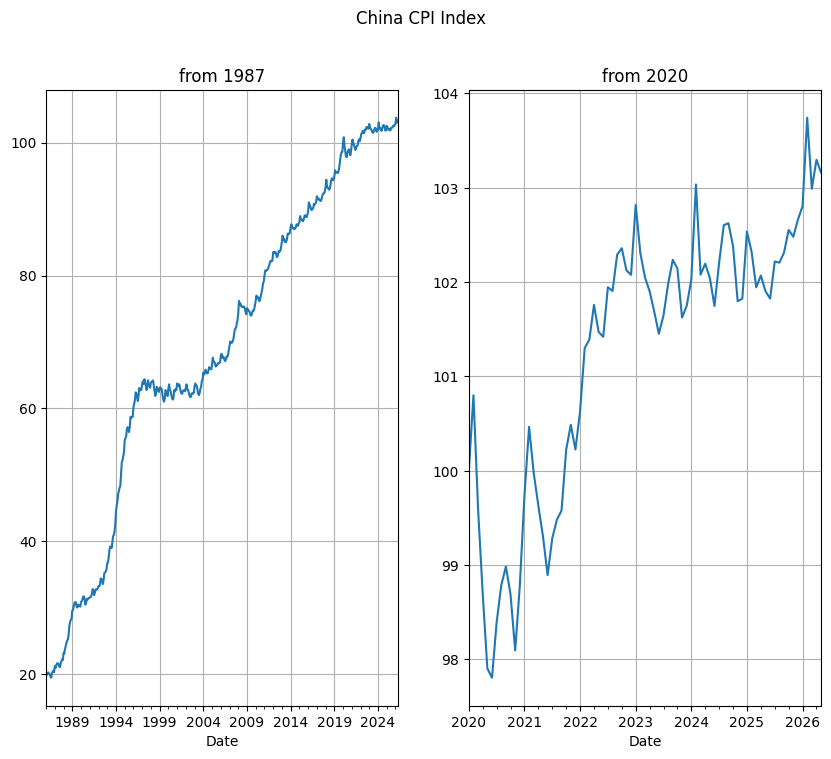

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cncpi['CPIIndex'].plot(ax=axs[0], title="from 1987")
cncpi[cncpi.index.year>=2020]['CPIIndex'].plot(ax=axs[1], title="from 2020")

#fig.autofmt_xdate()
for ax in axs:
    ax.grid(which='major')
plt.suptitle("China CPI Index")
plt.show()

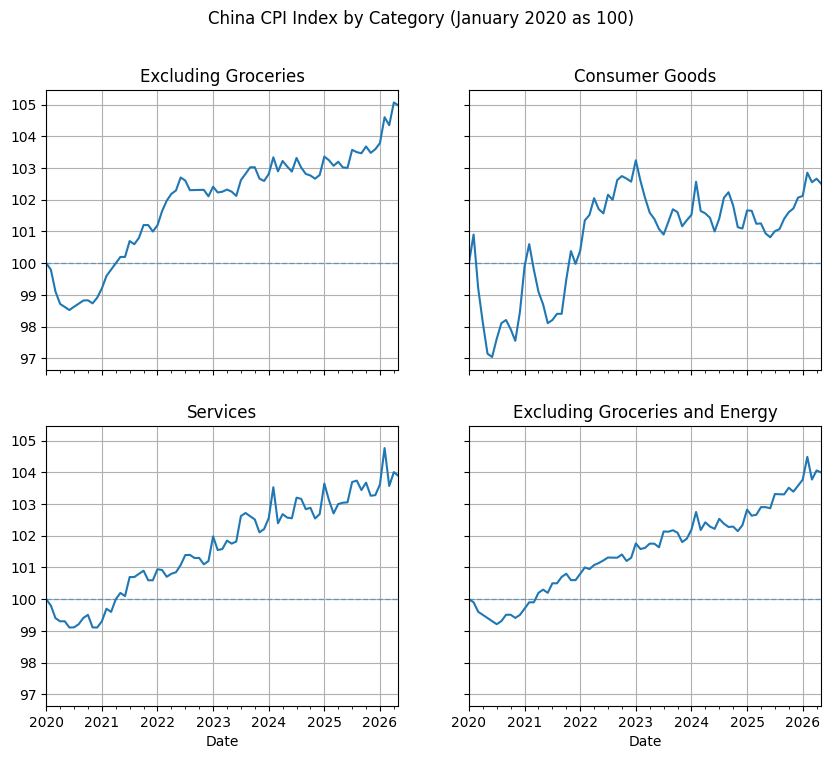

In [84]:
fig, axs = plt.subplots(2, 2, figsize=(10,8), sharey=True, sharex=True)

cncpi['CPIIndex excluding groceries'].dropna().plot(ax=axs[0 ,0], title="Excluding Groceries")
cncpi['CPIIndex of Consumer Goods'].dropna().plot(ax=axs[0, 1],title="Consumer Goods")
cncpi['CPIIndex of Services'].dropna().plot(ax=axs[1, 0], title="Services")
cncpi['CPIIndex excluding Groceries and Energy'].dropna().plot(ax=axs[1, 1], title="Excluding Groceries and Energy")

for ax in axs.flat:
    ax.axhline(100, linewidth=1, linestyle='--', alpha=0.5)
    ax.grid(which='major')

plt.suptitle("China CPI Index by Category (January 2020 as 100)")
plt.show()

In [85]:
# STL Charts generation
def STL_charts(series, title): 
    from statsmodels.tsa.seasonal import STL
    stl = STL(series, seasonal = 13)
    result = stl.fit()

    fig, axs = plt.subplots(3, 1, figsize=(10,8),sharex=True)

    axs[0].plot(result.observed, color='grey', label='Observed')
    axs[0].plot(result.trend, color='goldenrod', alpha=0.5, label='Trend')
    axs[0].legend()
    axs[0].set_title('Observed and Trend')

    axs[1].plot(result.seasonal, color='darkslategrey')
    axs[1].axhline(y=0, linestyle='--', color='darkslategrey', alpha=0.5)
    axs[1].set_title('Seasonal')

    axs[2].plot(result.resid, color='rebeccapurple')
    axs[2].axhline(y=0, linestyle='--', color='rebeccapurple', alpha=0.5)
    axs[2].set_title('Residual')

    plt.suptitle(f'STL Decomposition of {title}', fontsize=16)
    plt.tight_layout()
    fig.autofmt_xdate()

    plt.show()

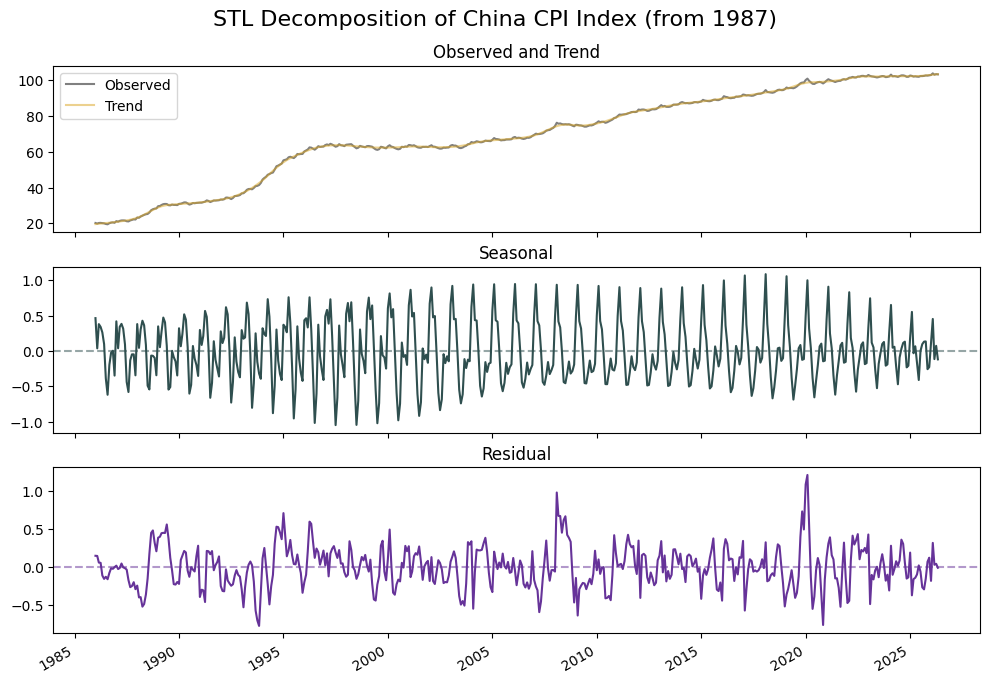

In [86]:
STL_charts(cncpi['CPIIndex'], "China CPI Index (from 1987)")

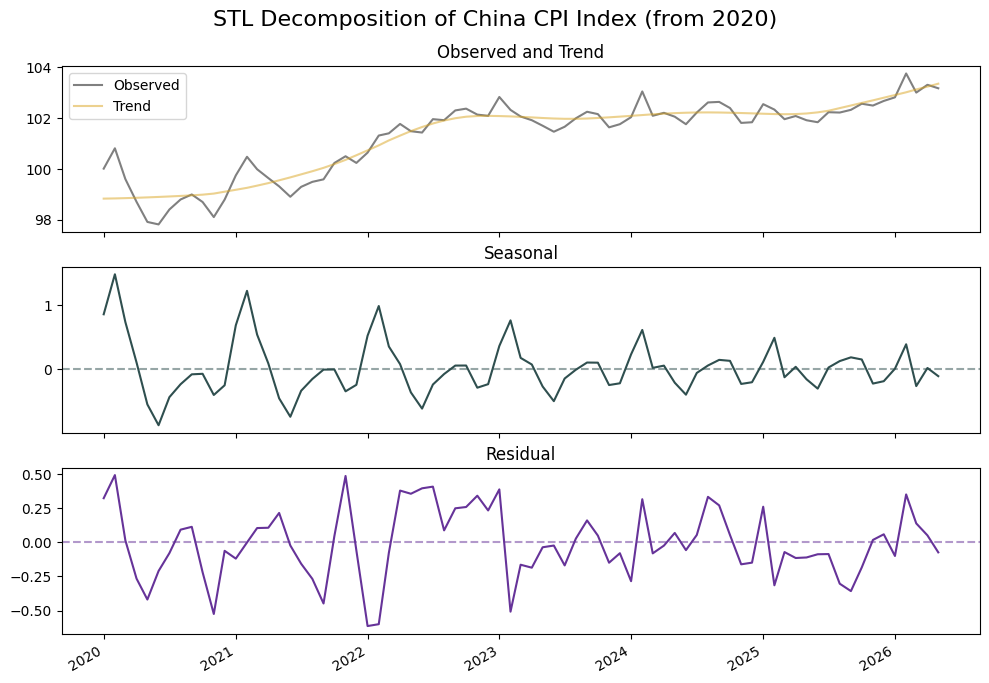

In [87]:
STL_charts(cncpi[cncpi.index.year>=2020]['CPIIndex'], "China CPI Index (from 2020)")

In [88]:
from statsmodels.tsa.filters.hp_filter import hpfilter

def HP_chart(series, title, lamb=129600):
    cycle, trend = hpfilter(series, lamb=lamb)

    decomp = pd.DataFrame(series)
    decomp['cycle'] = cycle
    decomp['trend'] = trend

    fig, axs = plt.subplots(2, 1, figsize=(10,8),sharex=True)

    axs[0].plot(decomp.iloc[:, 0], label='CPI Index')
    axs[0].plot(decomp['trend'], label='Trend')
    axs[0].legend()

    axs[1].plot(decomp['cycle'], label='Cycle')
    axs[1].axhline(y=0, linestyle='--', alpha=0.5)
    axs[1].legend()

    plt.suptitle(f'Hodrick–Prescott Filter of {title}')
    plt.show()

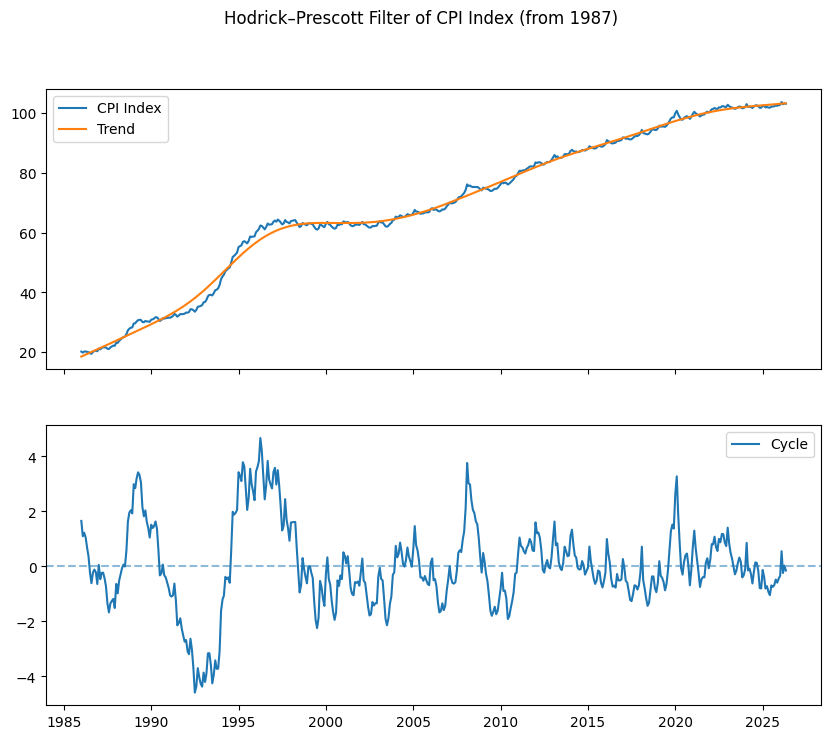

In [89]:
HP_chart(cncpi['CPIIndex'], 'CPI Index (from 1987)')

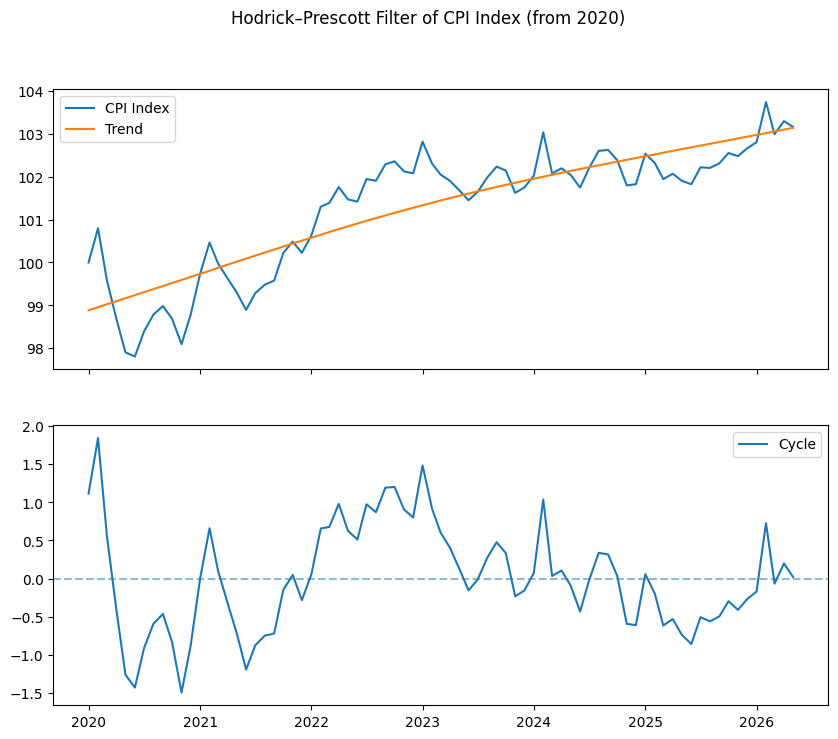

In [90]:
HP_chart(cncpi[cncpi.index.year>=2020]['CPIIndex'], 'CPI Index (from 2020)')

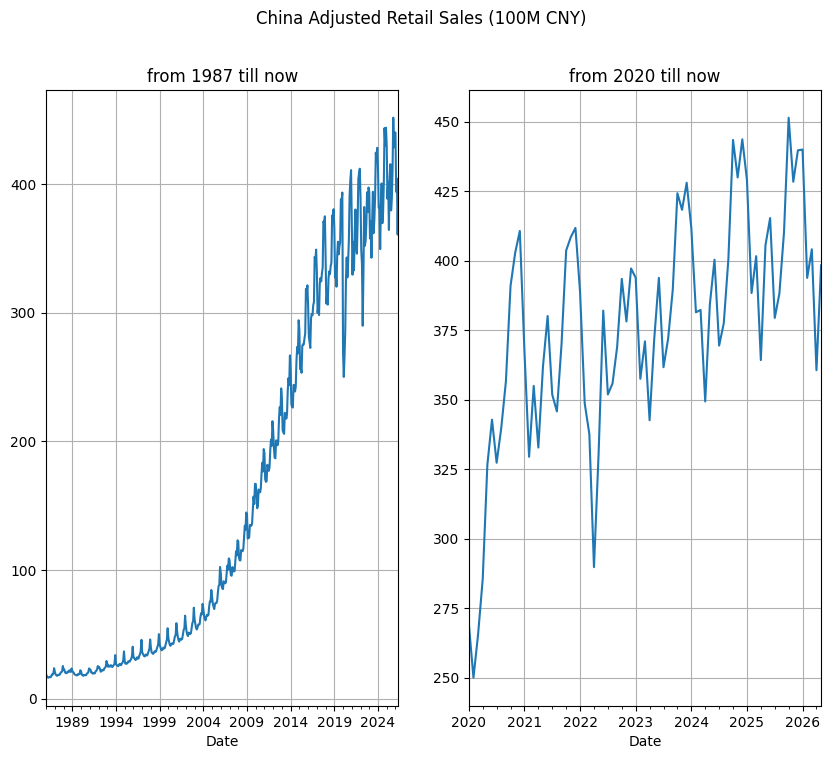

In [91]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cnadj['Adjusted Retail Sales (CNY 100M)'].plot(ax=axs[0], title="from 1987 till now")
cnadj[cnadj.index.year>=2020]['Adjusted Retail Sales (CNY 100M)'].plot(ax=axs[1], title="from 2020 till now")

for ax in axs.flat:
    ax.grid(which='major')

plt.suptitle("China Adjusted Retail Sales (100M CNY)")
plt.show()

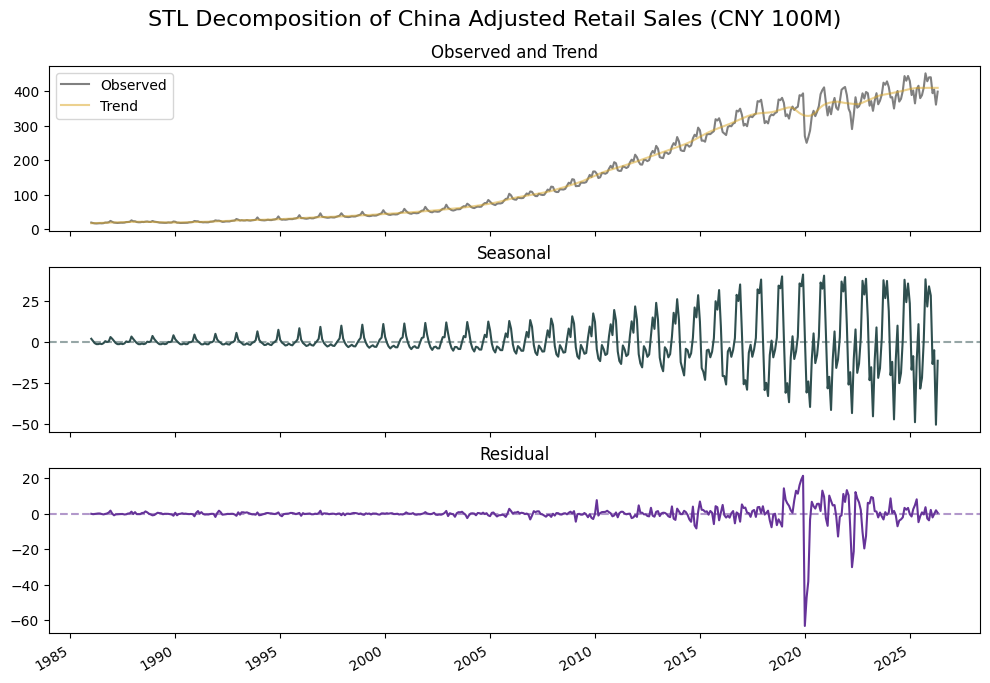

In [92]:
STL_charts(cnadj['Adjusted Retail Sales (CNY 100M)'], "China Adjusted Retail Sales (CNY 100M)")

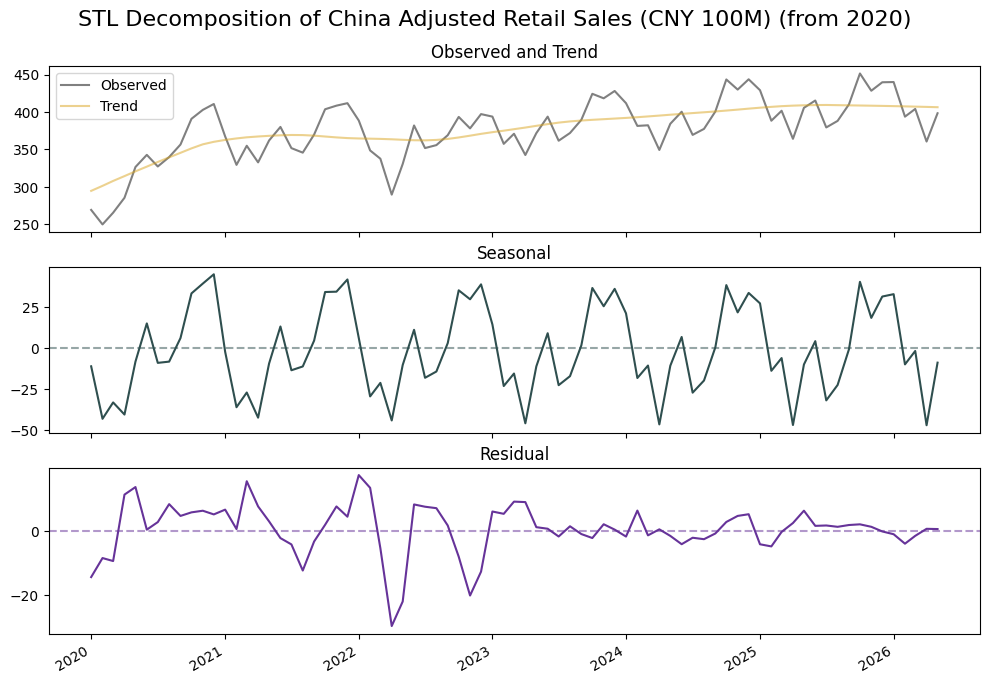

In [93]:
STL_charts(cnadj[cnadj.index.year>=2020]['Adjusted Retail Sales (CNY 100M)'], "China Adjusted Retail Sales (CNY 100M) (from 2020)")

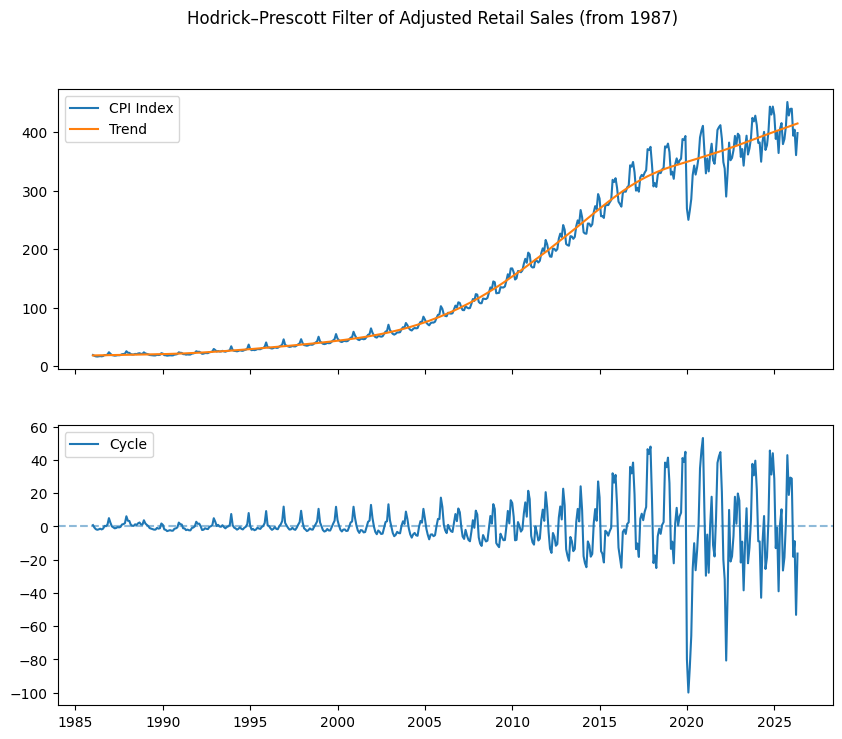

In [94]:
HP_chart(cnadj['Adjusted Retail Sales (CNY 100M)'], 'Adjusted Retail Sales (from 1987)')

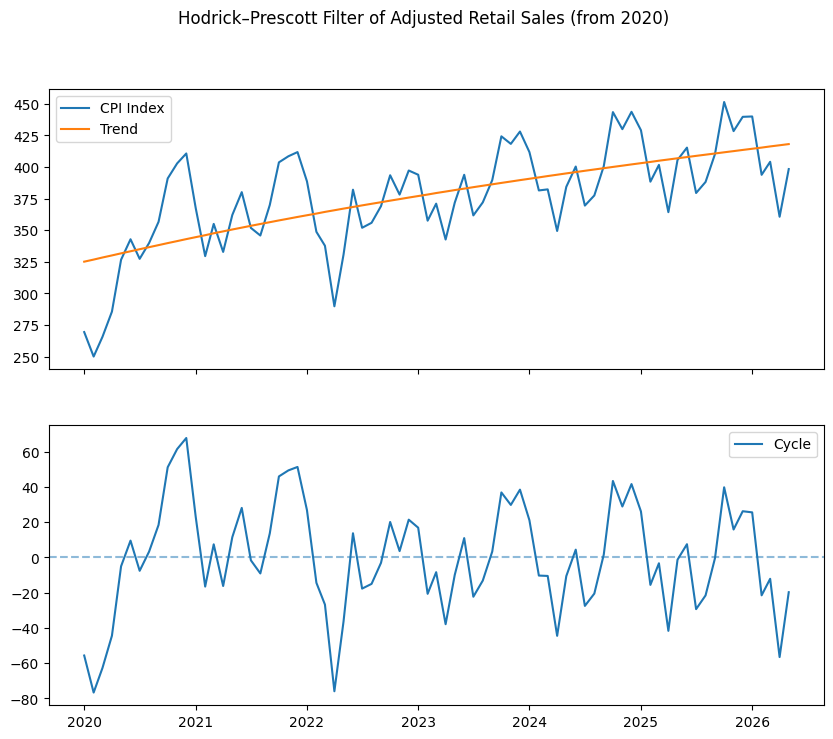

In [95]:
HP_chart(cnadj[cnadj.index.year>=2020]['Adjusted Retail Sales (CNY 100M)'], 'Adjusted Retail Sales (from 2020)')

Text(0.5, 1.0, 'Autocorrelation of CPI Index')

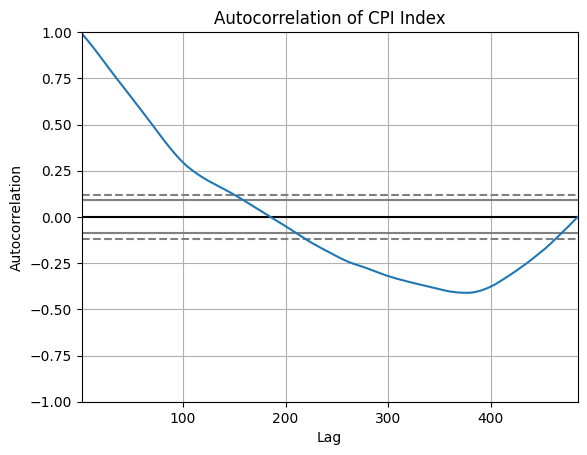

In [96]:
pd.plotting.autocorrelation_plot(cncpi['CPIIndex'])
plt.title("Autocorrelation of CPI Index")

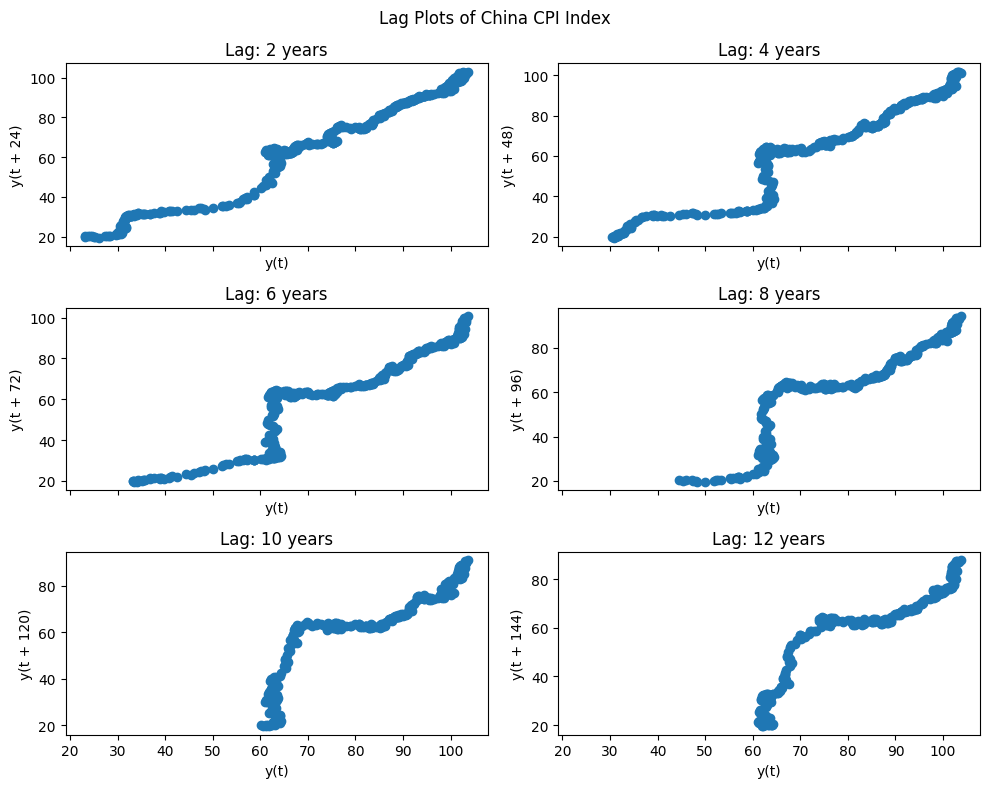

In [97]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cncpi['CPIIndex'], lag = 24 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} years")

plt.suptitle("Lag Plots of China CPI Index")
plt.tight_layout()
plt.show()

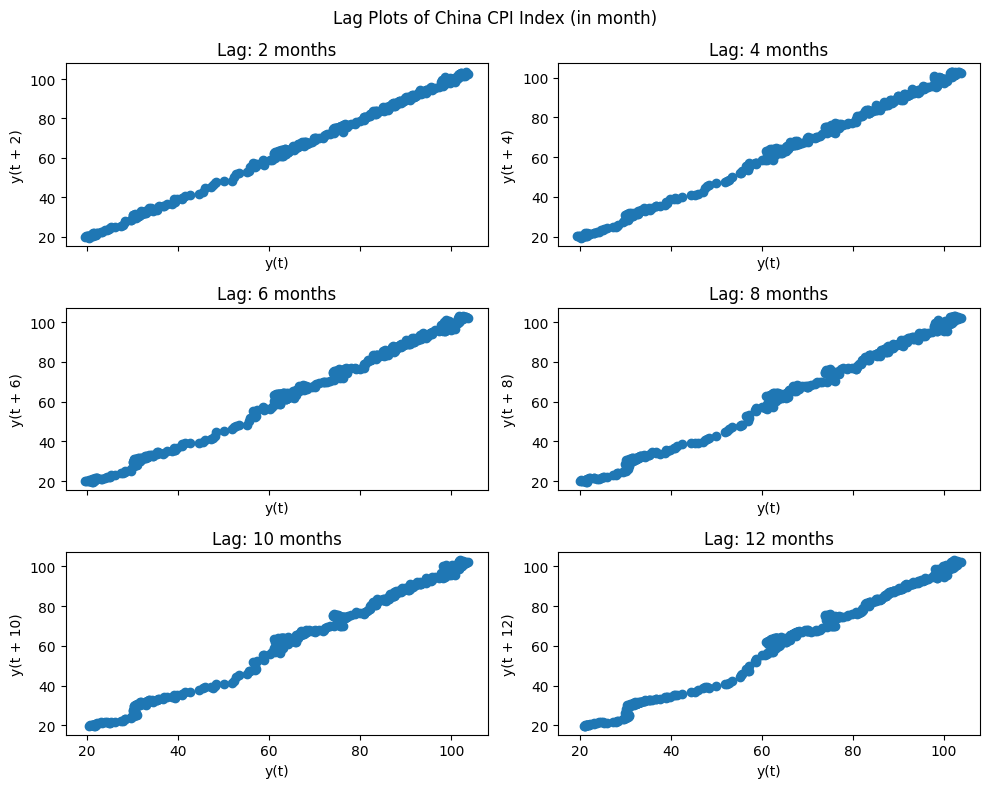

In [98]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cncpi['CPIIndex'], lag = 2 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} months")

plt.suptitle("Lag Plots of China CPI Index (in month)")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Autocorrelation of Adjusted Retail Sales')

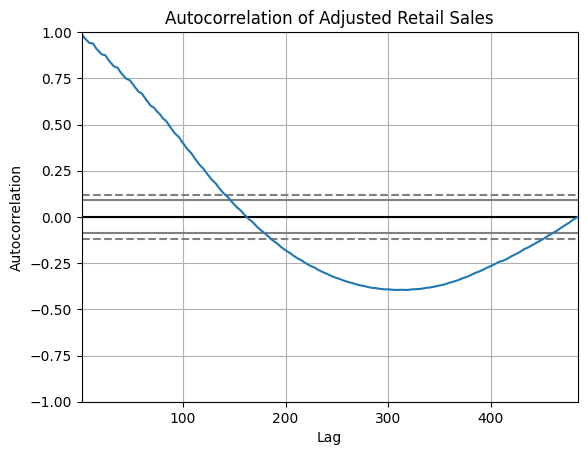

In [99]:
pd.plotting.autocorrelation_plot(cnadj['Adjusted Retail Sales (CNY 100M)'])
plt.title("Autocorrelation of Adjusted Retail Sales")

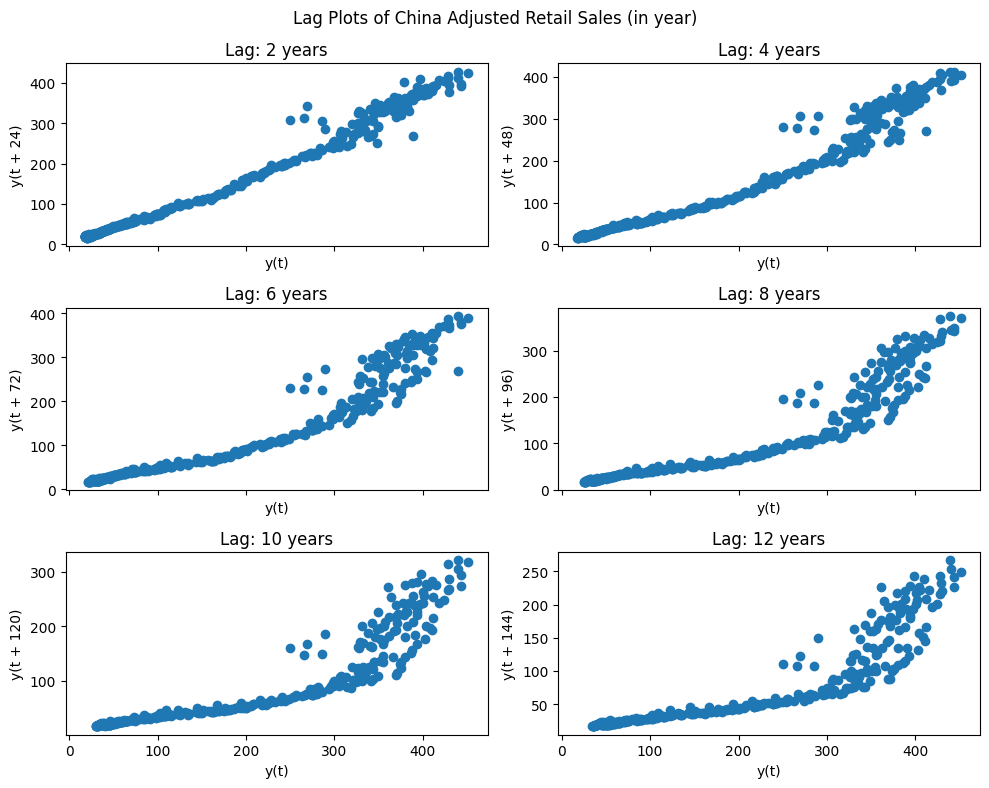

In [100]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cnadj['Adjusted Retail Sales (CNY 100M)'], lag = 24 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} years")

plt.suptitle("Lag Plots of China Adjusted Retail Sales (in year)")
plt.tight_layout()
plt.show()

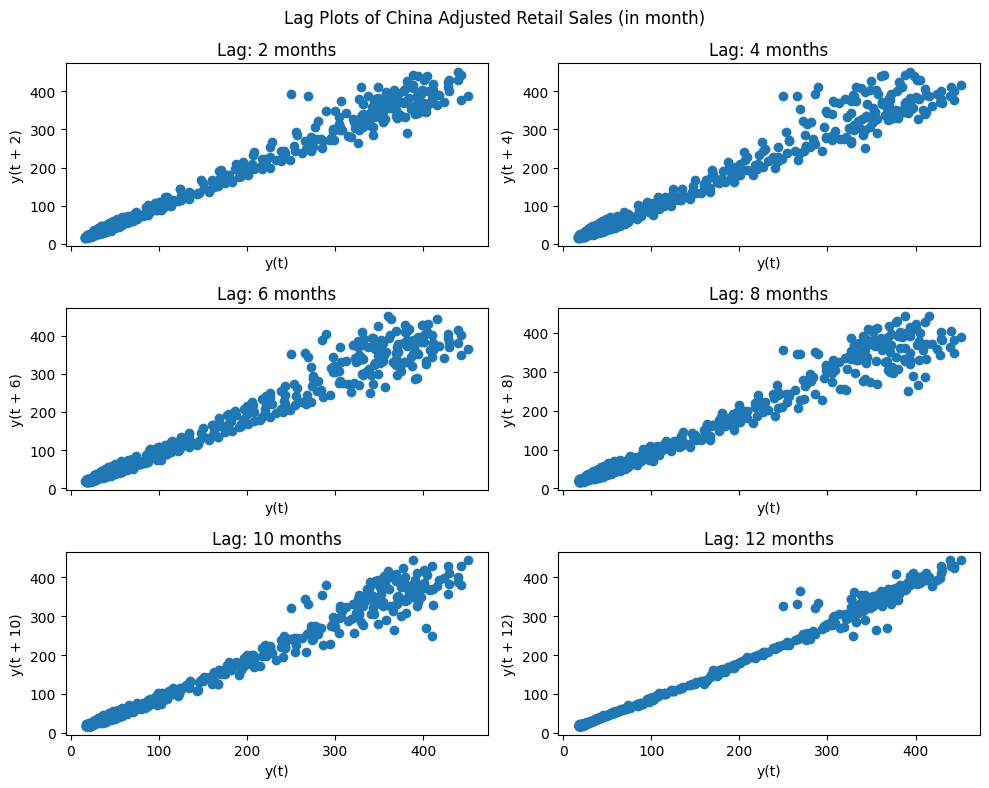

In [101]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cnadj['Adjusted Retail Sales (CNY 100M)'], lag = 2 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} months")

plt.suptitle("Lag Plots of China Adjusted Retail Sales (in month)")
plt.tight_layout()
plt.show()

In [102]:
cn_ppi_input = pd.read_csv('CN PPI Input Index.csv')
cn_ppi_output = pd.read_csv('CN PPI Output Index General.csv')
cn_ppi_input['Date'] = pd.to_datetime(cn_ppi_input['Date'])
cn_ppi_output['Date'] = pd.to_datetime(cn_ppi_output['Date'])
cn_ppi_output = cn_ppi_output[['Date', 'PPI Output Index']]

In [103]:
cn_ppi = cn_ppi_input[['Date', 'PPI Input Index']]
cn_ppi = cn_ppi.merge(cn_ppi_output, on='Date', how='outer')
cn_ppi = cn_ppi.set_index('Date')
cn_ppi = cn_ppi.join(cncpi['CPIIndex'])

In [104]:
cn_ppi['Diff (O-I)'] = cn_ppi['PPI Output Index'] - cn_ppi['PPI Input Index']
cn_ppi['Diff (C-O)'] = cn_ppi['CPIIndex'] - cn_ppi['PPI Output Index']
cn_ppi['Diff (C-I)'] = cn_ppi['CPIIndex'] - cn_ppi['PPI Input Index']
cn_ppi.head()

,PPI Input Index,PPI Output Index,CPIIndex,Diff (O-I),Diff (C-O),Diff (C-I)
Date,,,,,,
1992-01-01,NaN,44.515560,33.293287,NaN,-11.222274,NaN
1992-02-01,NaN,46.047018,33.225153,NaN,-12.821864,NaN
1992-03-01,NaN,45.508826,33.475334,NaN,-12.033492,NaN
1992-04-01,NaN,45.881440,34.395959,NaN,-11.485481,NaN
1992-05-01,NaN,46.100529,34.371909,NaN,-11.728620,NaN


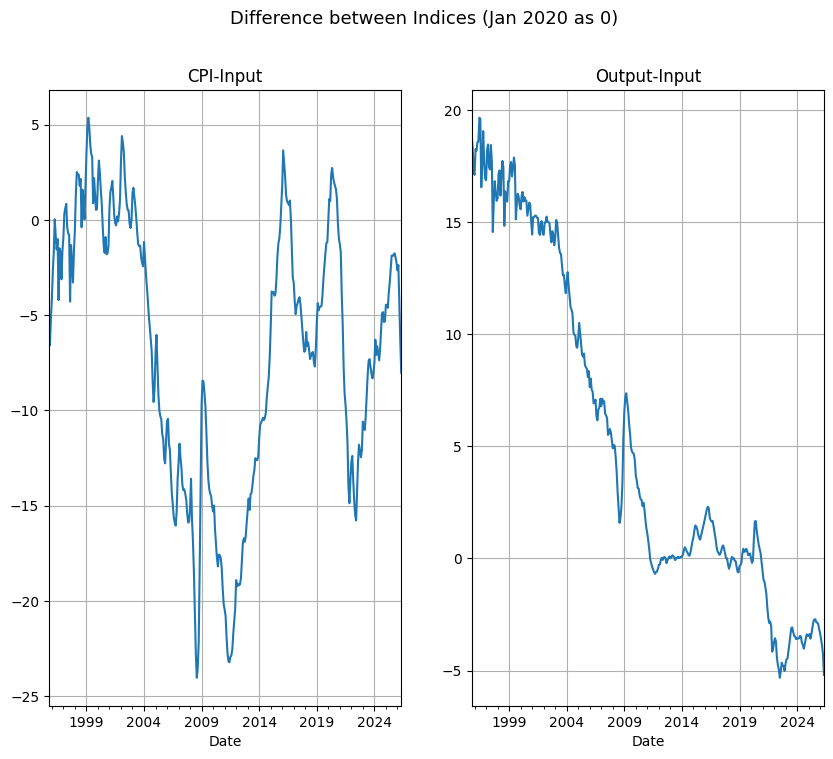

In [105]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cn_ppi['Diff (C-I)'].dropna().plot(ax=axs[0], title='CPI-Input', grid=True)
cn_ppi['Diff (O-I)'].dropna().plot(ax=axs[1], title='Output-Input', grid=True)

plt.suptitle("Difference between Indices (Jan 2020 as 0)", fontsize=13)
plt.show()

<Axes: title={'center': 'CPI-PPI Output'}, xlabel='Date'>

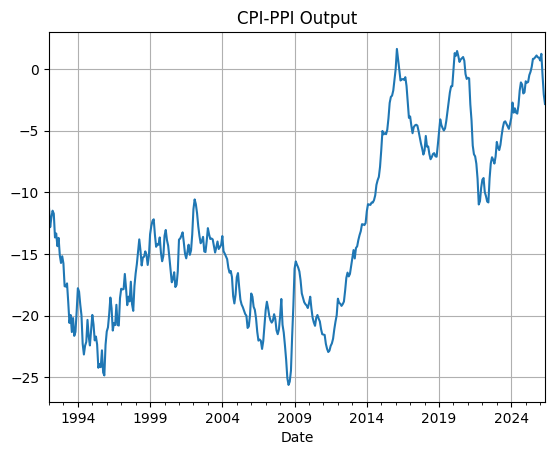

In [106]:
cn_ppi['Diff (C-O)'].plot(title='CPI-PPI Output', grid=True)

In [107]:
cncar = cnspe[['Date', '汽车类商品零售类值当期值(亿元)', '汽车类商品零售类值累计值(亿元)', '汽车类商品零售类值同比增长(%)']]
cncar = cncar.rename(columns={'汽车类商品零售类值当期值(亿元)': 'Car Sales (100M RMB)', '汽车类商品零售类值累计值(亿元)': 'Car Sales ToT (100m RMB)', '汽车类商品零售类值同比增长(%)': 'Car Sales YoY'})

In [108]:
cncar = fill_lunar_new_year_sales(cncar, sales_col='Car Sales (100M RMB)', cumulative_col='Car Sales ToT (100m RMB)')
cncar = cncar.set_index('Date')
cncar

,Car Sales (100M RMB),Car Sales ToT (100m RMB),Car Sales YoY
Date,,,
2026-05-01,3308.700000,16008.900000,-16.1
2026-04-01,3028.900000,12888.000000,-15.3
2026-03-01,3740.900000,9968.300000,-11.8
2026-02-01,2966.813559,6251.500000,NaN
2026-01-01,3284.686441,NaN,NaN
...,...,...,...
2000-05-01,33.861885,150.220588,NaN
2000-04-01,35.329560,116.086957,NaN
2000-03-01,34.200000,81.000000,NaN


In [109]:
cncar = cncar.join(cnadj['Retail Sales (CNY 100M)'], how='left')
cncar['Car Sales Percentage'] = cncar['Car Sales (100M RMB)']/cncar['Retail Sales (CNY 100M)']*100
cncar

,Car Sales (100M RMB),Car Sales ToT (100m RMB),Car Sales YoY,Retail Sales (CNY 100M),Car Sales Percentage
Date,,,,,
2026-05-01,3308.700000,16008.900000,-16.1,41090.00000,8.052324
2026-04-01,3028.900000,12888.000000,-15.3,37246.50000,8.132039
2026-03-01,3740.900000,9968.300000,-11.8,41616.00000,8.989091
2026-02-01,2966.813559,6251.500000,NaN,40851.00339,7.262523
2026-01-01,3284.686441,NaN,NaN,45227.89661,7.262523
...,...,...,...,...,...
2000-05-01,33.861885,150.220588,NaN,2636.90000,1.284155
2000-04-01,35.329560,116.086957,NaN,2571.50000,1.373889
2000-03-01,34.200000,81.000000,NaN,2626.60000,1.302064


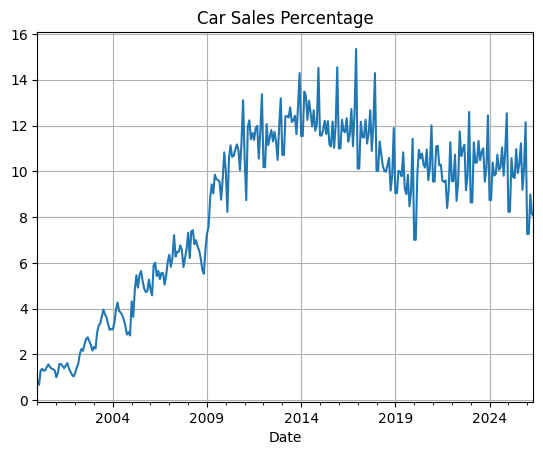

In [110]:
cncar['Car Sales Percentage'].plot(title='Car Sales Percentage')
plt.grid(which='major')

In [111]:
"""
years = cncar.index.year.unique()
ncols = 5
nrows = int(np.ceil(len(years) / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(10,8))

axs = np.array(axs).ravel()

for ax, year in zip(axs, years):
    data = cncar[cncar.index.year == year]

    ax.scatter(
        data['Retail Sales (CNY 100M)'],
        data['Car Sales (100M RMB)']
    )

    ax.set_title(f"Year {year}")

# Hide unused axes
for ax in axs[len(years):]:
    ax.set_visible(False)

fig.supxlabel('Retail Sales (CNY 100M)')
fig.supylabel('Car Sales (100M RMB)')
plt.tight_layout()
plt.show()
"""

'\nyears = cncar.index.year.unique()\nncols = 5\nnrows = int(np.ceil(len(years) / ncols))\n\nfig, axs = plt.subplots(nrows, ncols, figsize=(10,8))\n\naxs = np.array(axs).ravel()\n\nfor ax, year in zip(axs, years):\n    data = cncar[cncar.index.year == year]\n\n    ax.scatter(\n        data[\'Retail Sales (CNY 100M)\'],\n        data[\'Car Sales (100M RMB)\']\n    )\n\n    ax.set_title(f"Year {year}")\n\n# Hide unused axes\nfor ax in axs[len(years):]:\n    ax.set_visible(False)\n\nfig.supxlabel(\'Retail Sales (CNY 100M)\')\nfig.supylabel(\'Car Sales (100M RMB)\')\nplt.tight_layout()\nplt.show()\n'

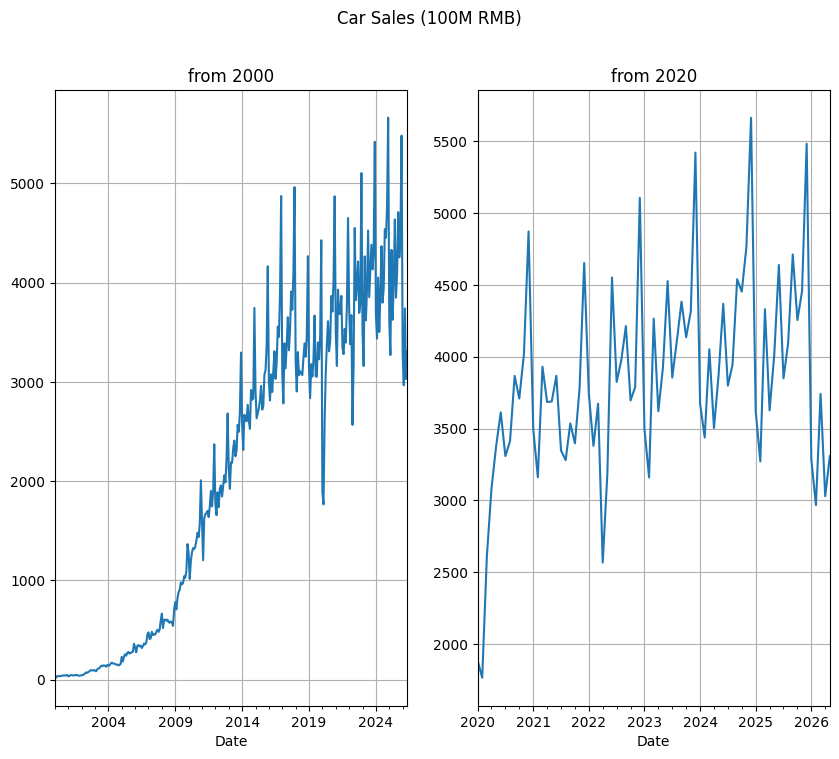

In [112]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cncar['Car Sales (100M RMB)'].plot(ax=axs[0], title="from 2000")
cncar[cncar.index.year>=2020]['Car Sales (100M RMB)'].plot(ax=axs[1], title="from 2020")

#fig.autofmt_xdate()
for ax in axs:
    ax.grid(which='major')
plt.suptitle("Car Sales (100M RMB)")
plt.show()

In [113]:
cncarcpi = pd.read_csv('CN Car CPI Index.csv', date_format='%Y-%m-%d')
cncarcpi['Date'] = pd.to_datetime(cncarcpi['Date'])
cncarcpi = cncarcpi.set_index('Date')

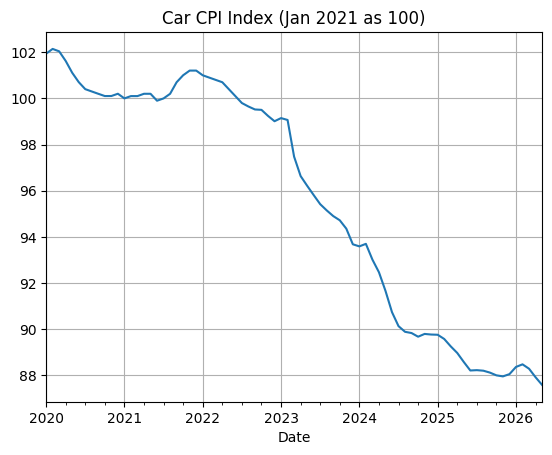

In [114]:
cncarcpi['Car CPI Index'].plot(title='Car CPI Index (Jan 2021 as 100)')
plt.grid(which='major')

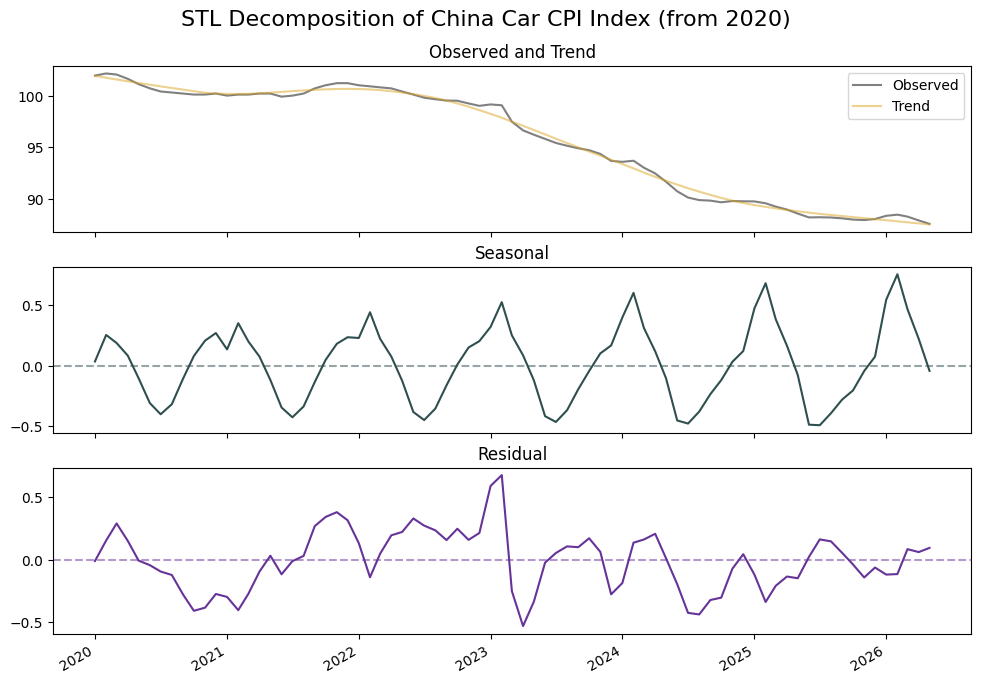

In [115]:
STL_charts(cncarcpi['Car CPI Index'], "China Car CPI Index (from 2020)")

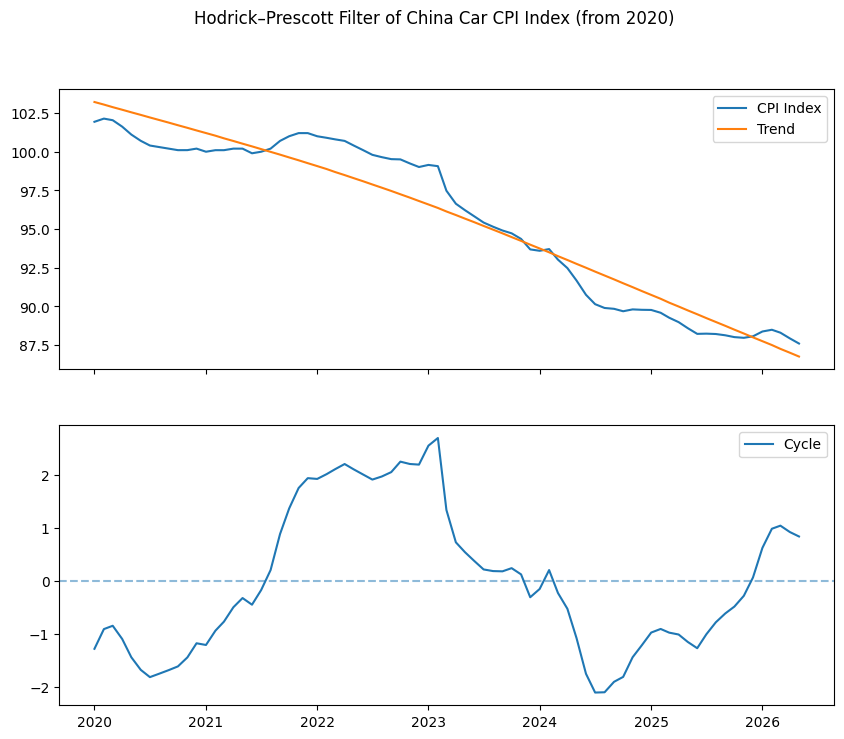

In [116]:
HP_chart(cncarcpi['Car CPI Index'], title="China Car CPI Index (from 2020)")

In [117]:
cncarcpi = cncarcpi.join(cncar, on='Date', how='left')
cncarcpi.head()

,Car CPI Index,Car Sales (100M RMB),Car Sales ToT (100m RMB),Car Sales YoY,Retail Sales (CNY 100M),Car Sales Percentage
Date,,,,,,
2020-01-01,101.936799,1887.951667,NaN,NaN,26933.73,7.009618
2020-02-01,102.142857,1766.148333,3654.1,NaN,25196.07,7.009618
2020-03-01,102.038736,2609.000000,6326.1,-18.1,26449.90,9.863931
2020-04-01,101.622819,3082.700000,9400.2,0.0,28177.80,10.940173
2020-05-01,101.110091,3376.100000,12784.5,3.5,31972.80,10.559288


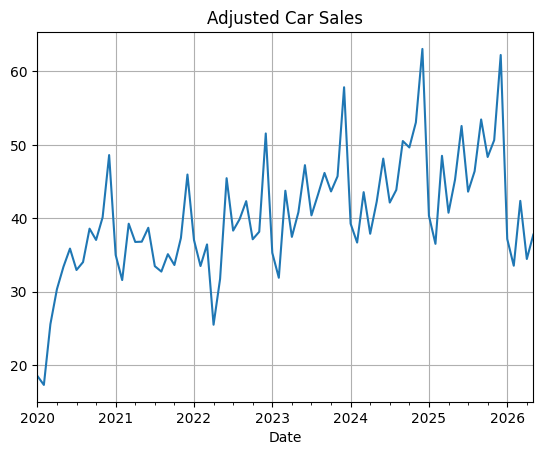

In [118]:
cncarcpi['Adjusted Car Sales (100M RMB)'] = cncarcpi['Car Sales (100M RMB)'] / cncarcpi['Car CPI Index']
cncarcpi['Adjusted Car Sales (100M RMB)'].plot(title='Adjusted Car Sales')
plt.grid(which='major')

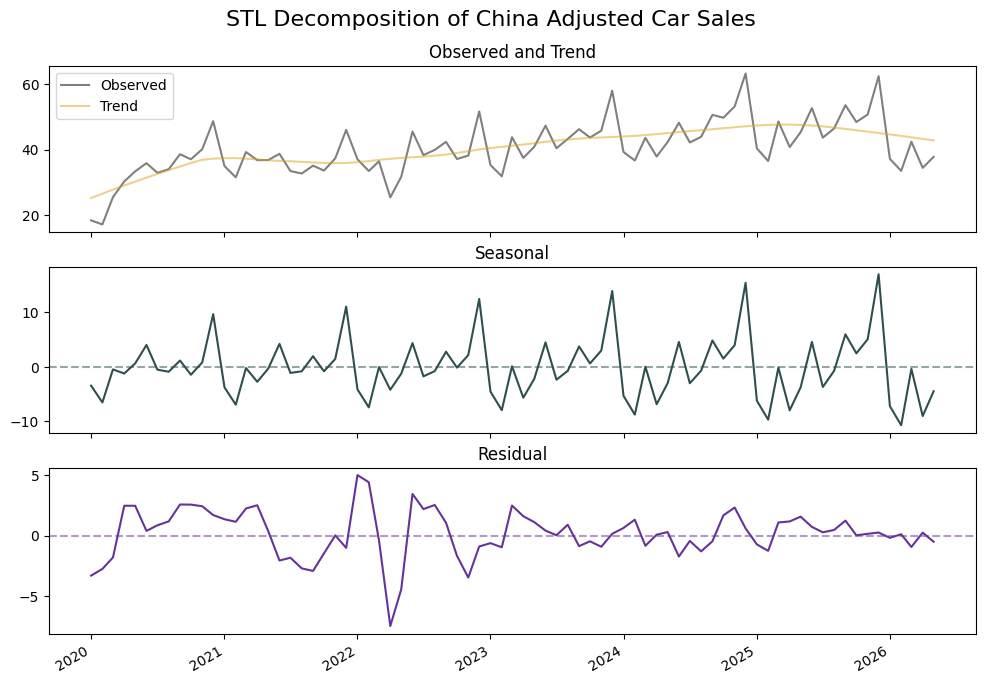

In [119]:
STL_charts(cncarcpi['Adjusted Car Sales (100M RMB)'], title='China Adjusted Car Sales')

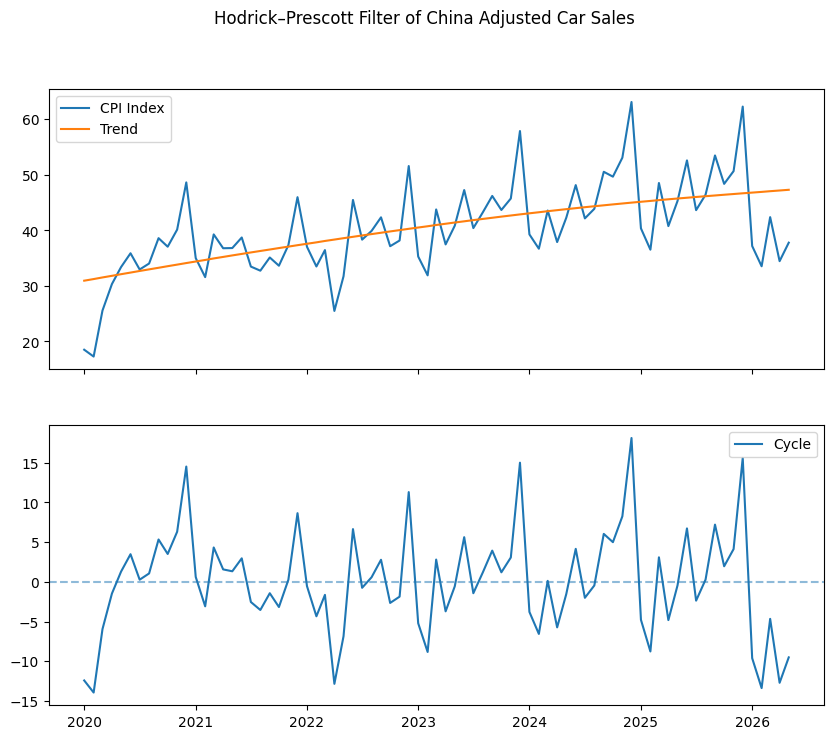

In [120]:
HP_chart(cncarcpi['Adjusted Car Sales (100M RMB)'], title="China Adjusted Car Sales")

In [121]:
car_ppi_output_yoy = pd.read_csv("CN PPI Output By Industry YoY (%).csv")
car_ppi_output_yoy = car_ppi_output_yoy[['Date', '汽车制造业工业生产者出厂价格指数 YoY']].dropna()
car_ppi_output_mom = pd.read_csv("CN PPI Output By Industry MoM (%).csv").reset_index()
car_ppi_output_mom = car_ppi_output_mom[['Date', '汽车制造业工业生产者出厂价格指数 MoM']].dropna()
#car_ppi_output = car_ppi_output_yoy.join(car_ppi_output_mom, on='Date', how='outer')
car_ppi_output_mom
#car_ppi_output

,Date,汽车制造业工业生产者出厂价格指数 MoM
0,2020-01-01,0.2
1,2020-02-01,0.0
2,2020-03-01,-0.1
3,2020-04-01,-0.1
4,2020-05-01,-0.1
...,...,...
72,2026-01-01,0.0
73,2026-02-01,-0.2
74,2026-03-01,-0.5
75,2026-04-01,0.1


In [124]:
from indexise import indexise
car_ppi_output_index = indexise(indexise)

NameError: name 'pd' is not defined